In [ ]:
from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from scipy.stats import pearsonr, spearmanr
from tqdm.auto import tqdm
from IPython.display import display

from data_utils import (
    RANDOM_STATE,
    IMAGE_SIZE,
    BATCH_SIZE,
    NUM_WORKERS,
    TARGET_COLUMNS,
    TARGET_NAMES,
    seed_everything,
    prepare_splits,
    build_transforms,
    PhotoQualityDataset,
    create_loaders,
)

In [2]:
seed_everything(RANDOM_STATE)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Пристрій:", device)

if device.type == "cuda":
    print("Відеокарта:", torch.cuda.get_device_name(0))
else:
    print("GPU не підключений.")

Пристрій: cpu
GPU не підключений.


In [3]:
DEBUG_MODE = True
NUM_EPOCHS = 7 if DEBUG_MODE else 20

LEARNING_RATE = 0.001
WEIGHT_DECAY = 0.0001
EARLY_STOPPING_PATIENCE = 5
MIN_DELTA = 0.00001

MODEL_NAME = "Custom CNN"
MODEL_PREFIX = "custom_cnn"
ARCHITECTURE = "custom_cnn"
TRAINING_STRATEGY = "Custom CNN"

In [4]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

MANIFEST_PATH = PROJECT_ROOT / "data" / "processed" / "dataset_manifest.csv"
IMAGES_DIRECTORY = PROJECT_ROOT / "data" / "raw" / "SPAQ_small"

MODELS_DIRECTORY = PROJECT_ROOT / "artifacts" / "models"
RESULTS_DIRECTORY = PROJECT_ROOT / "artifacts" / "results"

MODELS_DIRECTORY.mkdir(parents=True, exist_ok=True)
RESULTS_DIRECTORY.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODELS_DIRECTORY / f"{MODEL_PREFIX}_best.pt"
HISTORY_PATH = RESULTS_DIRECTORY / f"{MODEL_PREFIX}_history.csv"
METRICS_PATH = RESULTS_DIRECTORY / f"{MODEL_PREFIX}_metrics.csv"
TARGET_METRICS_PATH = RESULTS_DIRECTORY / f"{MODEL_PREFIX}_metrics_by_target.csv"
PREDICTIONS_PATH = RESULTS_DIRECTORY / f"{MODEL_PREFIX}_predictions.csv"

LOSS_PLOT_PATH = RESULTS_DIRECTORY / f"{MODEL_PREFIX}_loss.png"
SCATTER_PLOT_PATH = RESULTS_DIRECTORY / f"{MODEL_PREFIX}_scatter.png"

print("Manifest:", MANIFEST_PATH)
print("Фотографії:", IMAGES_DIRECTORY)
print("Модель:", MODEL_PATH)
print("Результати:", RESULTS_DIRECTORY)

Manifest: c:\Users\Admin\Desktop\PhotoAnalyser\data\processed\dataset_manifest.csv
Фотографії: c:\Users\Admin\Desktop\PhotoAnalyser\data\raw\SPAQ_small
Модель: c:\Users\Admin\Desktop\PhotoAnalyser\artifacts\models\custom_cnn_best.pt
Результати: c:\Users\Admin\Desktop\PhotoAnalyser\artifacts\results


Підготовка даних

In [5]:
manifest = pd.read_csv(MANIFEST_PATH)

print("Розмір:", manifest.shape)

display(
    manifest["split"]
    .value_counts()
    .to_frame("Кількість")
)

Розмір: (11125, 12)


,Кількість
split,
train,7787
test,1669
validation,1669


In [6]:
train_transform, evaluation_transform = build_transforms(
    image_size=IMAGE_SIZE,
)

In [7]:
train_dataframe, validation_dataframe, test_dataframe = prepare_splits(
    manifest=manifest,
    debug_mode=DEBUG_MODE,
    random_state=RANDOM_STATE,
)

print("Train:", len(train_dataframe))
print("Validation:", len(validation_dataframe))
print("Test:", len(test_dataframe))

Train: 3000
Validation: 600
Test: 600


In [8]:
train_dataset = PhotoQualityDataset(
    dataframe=train_dataframe,
    images_directory=IMAGES_DIRECTORY,
    target_columns=TARGET_COLUMNS,
    transform=train_transform,
)

validation_dataset = PhotoQualityDataset(
    dataframe=validation_dataframe,
    images_directory=IMAGES_DIRECTORY,
    target_columns=TARGET_COLUMNS,
    transform=evaluation_transform,
)

test_dataset = PhotoQualityDataset(
    dataframe=test_dataframe,
    images_directory=IMAGES_DIRECTORY,
    target_columns=TARGET_COLUMNS,
    transform=evaluation_transform,
)

print("Train:", len(train_dataset))
print("Validation:", len(validation_dataset))
print("Test:", len(test_dataset))

Train: 3000
Validation: 600
Test: 600


In [9]:
train_loader, validation_loader, test_loader = create_loaders(
    train_dataset=train_dataset,
    validation_dataset=validation_dataset,
    test_dataset=test_dataset,
    device=device,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    random_state=RANDOM_STATE,
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(validation_loader))
print("Test batches:", len(test_loader))

Train batches: 188
Validation batches: 38
Test batches: 38


Архітектура моделі

In [ ]:
class CustomCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                padding=1,
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1,
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1,
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(
                in_channels=128,
                out_channels=256,
                kernel_size=3,
                padding=1,
            ),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.shared_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(p=0.3),
        )

        self.quality_head = nn.Linear(128, 1)

        self.attributes_head = nn.Linear(128, 5)

    def forward(self, images):
        features = self.features(images)
        shared_features = self.shared_layers(features)

        quality = self.quality_head(shared_features)
        attributes = self.attributes_head(shared_features)

        outputs = torch.cat(
            [quality, attributes],
            dim=1,
        )

        outputs = torch.sigmoid(outputs)

        return outputs

In [11]:
model = CustomCNN().to(device)

print(model)

CustomCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affin

In [12]:
total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(f"Усього параметрів: {total_parameters:,}")
print(f"Навчуваних параметрів: {trainable_parameters:,}")

Усього параметрів: 423,046
Навчуваних параметрів: 423,046


Loss, optimizer, scheduler

In [15]:
criterion = nn.MSELoss()

In [16]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

In [17]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2,
)

Функції для навчання

In [18]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0

    progress_bar = tqdm(dataloader, desc="Train", leave=False)

    for images, targets, _ in progress_bar:
        images = images.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        predictions = model(images)
        loss = criterion(predictions, targets)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        progress_bar.set_postfix(loss=f"{loss.item():.5f}")

    return total_loss / len(dataloader.dataset)

In [19]:
def evaluate_loss(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for images, targets, _ in tqdm(
            dataloader,
            desc="Validation",
            leave=False,
        ):
            images = images.to(device)
            targets = targets.to(device)

            predictions = model(images)
            loss = criterion(predictions, targets)

            total_loss += loss.item() * images.size(0)

    return total_loss / len(dataloader.dataset)

In [20]:
history = []

best_validation_loss = float("inf")
epochs_without_improvement = 0
best_epoch = 0

Навчання моделі

In [ ]:
training_start_time = time.perf_counter()

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\nЕпоха {epoch}/{NUM_EPOCHS}")

    current_learning_rate = optimizer.param_groups[0]["lr"]

    train_loss = train_one_epoch(
        model=model,
        dataloader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
    )

    validation_loss = evaluate_loss(
        model=model,
        dataloader=validation_loader,
        criterion=criterion,
        device=device,
    )

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "validation_loss": validation_loss,
        "backbone_learning_rate": current_learning_rate,
        "head_learning_rate": current_learning_rate,
    })

    print(f"Train loss: {train_loss:.6f}")
    print(f"Validation loss: {validation_loss:.6f}")
    print(f"Learning rate: {current_learning_rate:.7f}")

    scheduler.step(validation_loss)

    if validation_loss < best_validation_loss - MIN_DELTA:
        best_validation_loss = validation_loss
        best_epoch = epoch
        epochs_without_improvement = 0

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "architecture": ARCHITECTURE,
                "training_strategy": TRAINING_STRATEGY,
                "target_columns": TARGET_COLUMNS,
                "image_size": IMAGE_SIZE,
                "random_state": RANDOM_STATE,
                "best_epoch": best_epoch,
                "best_validation_loss": best_validation_loss,
            },
            MODEL_PATH,
        )

        print("Збережено нову найкращу модель")
    else:
        epochs_without_improvement += 1
        print("Епох без покращення:", epochs_without_improvement)

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print("\nEarly stopping")
        break

training_time_seconds = time.perf_counter() - training_start_time
history_dataframe = pd.DataFrame(history)


Епоха 1/7


Train:   0%|          | 0/188 [00:00<?, ?it/s]

Validation:   0%|          | 0/38 [00:00<?, ?it/s]

Train loss: 0.022485
Validation loss: 0.019326
Learning rate: 0.0010000
Збережено нову найкращу модель

Епоха 2/7


Train:   0%|          | 0/188 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/38 [00:00<?, ?it/s]

Train loss: 0.017154
Validation loss: 0.016638
Learning rate: 0.0010000
Епох без покращення: 3

Епоха 7/7


Train:   0%|          | 0/188 [00:00<?, ?it/s]

Validation:   0%|          | 0/38 [00:00<?, ?it/s]

Train loss: 0.015322
Validation loss: 0.012794
Learning rate: 0.0005000
Збережено нову найкращу модель


In [22]:
print("Найкраща епоха:", best_epoch)
print("Найкращий validation loss:", round(best_validation_loss, 6))
print("Час навчання, хв:", round(training_time_seconds / 60, 2))
print("Модель збережена:", MODEL_PATH)

Найкраща епоха: 7
Найкращий validation loss: 0.012794
Час навчання, хв: 23.05
Модель збережена: c:\Users\Admin\Desktop\PhotoAnalyser\artifacts\models\custom_cnn_best.pt


Графік навчання train/validation loss по епохах

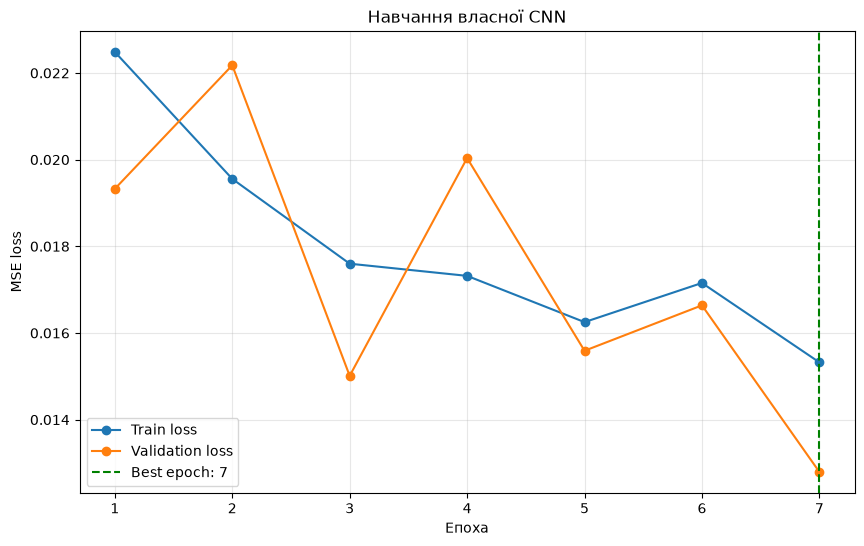

In [26]:
epochs = history_dataframe["epoch"]

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    history_dataframe["train_loss"],
    marker="o",
    label="Train loss",
)

plt.plot(
    epochs,
    history_dataframe["validation_loss"],
    marker="o",
    label="Validation loss",
)

plt.axvline(
    best_epoch,
    color="green",
    linestyle="--",
    label=f"Best epoch: {best_epoch}",
)

plt.xlabel("Епоха")
plt.ylabel("MSE loss")
plt.title("Навчання власної CNN")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(LOSS_PLOT_PATH, dpi=150, bbox_inches="tight")
plt.show()

In [27]:
history_dataframe.to_csv(
    HISTORY_PATH,
    index=False,
    encoding="utf-8-sig",
)

display(history_dataframe)

,epoch,train_loss,validation_loss,backbone_learning_rate,head_learning_rate
0,1,0.022485,0.019326,0.0010,0.0010
1,2,0.019556,0.022177,0.0010,0.0010
2,3,0.017599,0.015011,0.0010,0.0010
3,4,0.017318,0.020036,0.0010,0.0010
4,5,0.016251,0.015590,0.0010,0.0010
5,6,0.017154,0.016638,0.0010,0.0010
6,7,0.015322,0.012794,0.0005,0.0005


Оцінка на test

In [28]:
checkpoint = torch.load(
    MODEL_PATH,
    map_location=device,
    weights_only=True,
)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Завантажено модель з епохи:", checkpoint["best_epoch"])

Завантажено модель з епохи: 7


In [ ]:
def predict_dataset(model, dataloader, device):
    model.eval()

    all_predictions = []
    all_targets = []
    all_image_names = []

    with torch.no_grad():
        for images, targets, image_names in tqdm(
            dataloader,
            desc="Test predictions",
        ):
            images = images.to(device)
            predictions = model(images)

            all_predictions.append(predictions.cpu().numpy())
            all_targets.append(targets.numpy())
            all_image_names.extend(image_names)

    predictions = np.concatenate(all_predictions, axis=0) * 100.0
    targets = np.concatenate(all_targets, axis=0) * 100.0

    return predictions, targets, all_image_names

In [30]:
test_predictions, test_targets, test_image_names = predict_dataset(
    model=model,
    dataloader=test_loader,
    device=device,
)

print("Прогнози:", test_predictions.shape)
print("Правильні оцінки:", test_targets.shape)

Test predictions:   0%|          | 0/38 [00:00<?, ?it/s]

Прогнози: (600, 6)
Правильні оцінки: (600, 6)


Метрики якості
MAE, RMSE, PLCC, SRCC по кожному параметру

In [31]:
mae_values = np.mean(
    np.abs(test_predictions - test_targets),
    axis=0,
)

rmse_values = np.sqrt(
    np.mean(
        (test_predictions - test_targets) ** 2,
        axis=0,
    )
)

In [32]:
metrics_rows = []

for index, target_column in enumerate(TARGET_COLUMNS):
    true_values = test_targets[:, index]
    predicted_values = test_predictions[:, index]

    metrics_rows.append({
        "target_column": target_column,
        "parameter": TARGET_NAMES[index],
        "mae": mae_values[index],
        "rmse": rmse_values[index],
        "plcc": pearsonr(true_values, predicted_values)[0],
        "srcc": spearmanr(true_values, predicted_values)[0],
    })  

metrics_dataframe = pd.DataFrame(metrics_rows)

metrics_dataframe.to_csv(
    TARGET_METRICS_PATH,
    index=False,
    encoding="utf-8-sig",
)

display(metrics_dataframe.round(4))

,target_column,parameter,mae,rmse,plcc,srcc
0,overall_quality,Загальна якість,8.8843,11.3033,0.8469,0.8415
1,brightness_quality,Яскравість,8.1003,10.3066,0.7879,0.7341
2,colorfulness_quality,Кольоровість,8.0793,9.9758,0.7548,0.7151
3,contrast_quality,Контраст,7.9915,10.0100,0.7827,0.7455
4,noise_quality,Якість щодо шуму,9.5869,11.9650,0.7682,0.7731
5,sharpness_quality,Різкість,9.9922,12.9512,0.8516,0.8370


In [33]:
true_overall = test_targets[:, 0]
predicted_overall = test_predictions[:, 0]

overall_metrics = metrics_dataframe.iloc[0]

print(f"Overall MAE: {overall_metrics['mae']:.3f}")
print(f"Overall RMSE: {overall_metrics['rmse']:.3f}")
print(f"PLCC: {overall_metrics['plcc']:.4f}")
print(f"SRCC: {overall_metrics['srcc']:.4f}")

Overall MAE: 8.884
Overall RMSE: 11.303
PLCC: 0.8469
SRCC: 0.8415


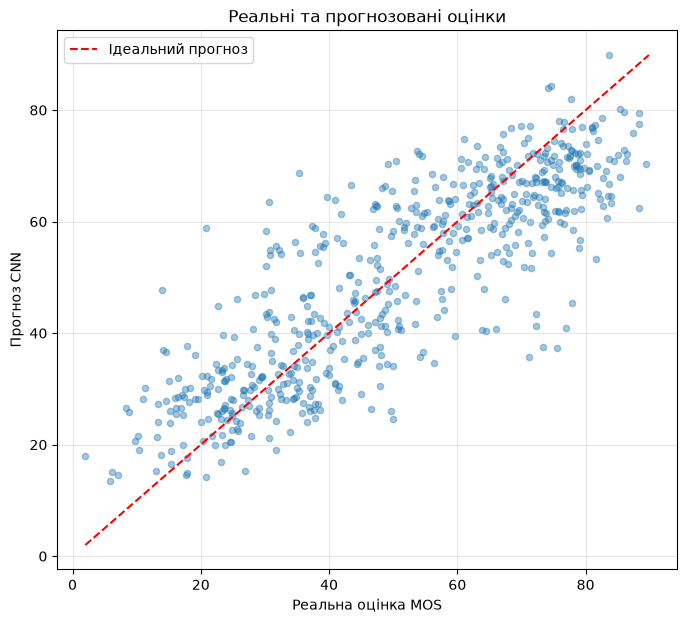

In [34]:
plt.figure(figsize=(8, 7))

plt.scatter(
    true_overall,
    predicted_overall,
    alpha=0.4,
    s=20,
)

minimum_score = min(
    true_overall.min(),
    predicted_overall.min(),
)

maximum_score = max(
    true_overall.max(),
    predicted_overall.max(),
)

plt.plot(
    [minimum_score, maximum_score],
    [minimum_score, maximum_score],
    color="red",
    linestyle="--",
    label="Ідеальний прогноз",
)

plt.xlabel("Реальна оцінка MOS")
plt.ylabel("Прогноз CNN")
plt.title("Реальні та прогнозовані оцінки")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(SCATTER_PLOT_PATH, dpi=150, bbox_inches="tight")
plt.show()

Аналіз помилок

In [35]:
predictions_dataframe = pd.DataFrame({
    "image_name": test_image_names,
})

for index, column in enumerate(TARGET_COLUMNS):
    predictions_dataframe[
        f"true_{column}"
    ] = test_targets[:, index]

    predictions_dataframe[
        f"predicted_{column}"
    ] = test_predictions[:, index]

In [36]:
predictions_dataframe["overall_error"] = np.abs(
    predictions_dataframe["true_overall_quality"]
    - predictions_dataframe[
        "predicted_overall_quality"
    ]
)

display(predictions_dataframe.head())

,image_name,true_overall_quality,predicted_overall_quality,true_brightness_quality,predicted_brightness_quality,true_colorfulness_quality,predicted_colorfulness_quality,true_contrast_quality,predicted_contrast_quality,true_noise_quality,predicted_noise_quality,true_sharpness_quality,predicted_sharpness_quality,overall_error
0,03280.jpg,15.410000,18.894228,18.270000,19.504528,26.670000,30.560976,21.500000,26.971201,24.559999,26.278696,10.750000,14.907045,3.484228
1,04131.jpg,73.570000,57.305138,70.709999,58.381336,70.290001,62.397774,75.860001,59.793121,67.290001,56.498085,73.709999,54.907185,16.264862
2,06680.jpg,34.430000,31.525242,45.430000,52.674110,37.139999,54.646175,40.570000,50.492626,28.430000,38.230507,17.000000,20.551659,2.904758
3,08880.jpg,86.000000,72.926178,84.669998,71.450447,86.330002,74.522812,85.000000,72.850594,86.779999,71.056824,85.330002,73.751999,13.073822
4,09996.jpg,34.709999,56.405926,51.570000,61.254841,46.000000,64.789513,43.000000,61.856503,25.000000,57.032196,21.139999,52.158512,21.695927


In [37]:
print("Найточніші прогнози:")

display(
    predictions_dataframe
    .sort_values("overall_error")
    .head(10)
)

Найточніші прогнози:


,image_name,true_overall_quality,predicted_overall_quality,true_brightness_quality,predicted_brightness_quality,true_colorfulness_quality,predicted_colorfulness_quality,true_contrast_quality,predicted_contrast_quality,true_noise_quality,predicted_noise_quality,true_sharpness_quality,predicted_sharpness_quality,overall_error
368,05068.jpg,68.449997,68.441772,67.099998,65.392372,74.900002,68.964935,72.199997,67.286842,73.699997,66.684097,72.360001,69.203636,0.008224
91,00567.jpg,47.549999,47.510891,54.290001,56.919025,60.619999,60.129410,53.910000,56.714619,34.099998,50.037258,43.220001,41.140308,0.039108
373,03591.jpg,39.639999,39.576527,63.450005,56.699711,58.180000,59.297829,54.400002,55.041485,39.639999,44.597317,25.730000,30.026600,0.063473
277,04564.jpg,76.419998,76.533928,78.730003,76.928040,78.449997,79.837151,77.639999,78.234932,74.730003,74.580505,78.820000,77.029114,0.113930
383,01151.jpg,65.250000,65.396324,67.879997,61.826134,75.860001,66.642418,73.570000,64.937149,67.000000,64.456917,68.500000,66.083977,0.146324
207,00078.jpg,67.139999,67.288460,66.430000,66.916046,70.000000,70.184113,72.000000,68.217445,68.129997,65.916801,66.250000,66.970375,0.148460
509,00480.jpg,72.379997,72.186928,72.750000,72.822456,78.500000,76.162857,70.879997,74.310654,72.250000,70.585899,63.500000,72.204079,0.193069
518,00698.jpg,49.000000,48.797157,29.000000,46.775997,51.290001,53.909439,40.709999,49.824982,60.170002,52.801109,44.570000,50.674812,0.202843
296,10901.jpg,21.709999,21.482859,38.330002,26.819643,21.570000,35.368271,28.570000,31.796337,23.830000,27.798567,24.430000,15.871401,0.227140
166,00797.jpg,17.860001,17.623863,12.290000,23.462063,34.290001,32.919346,20.860001,24.609726,31.000000,27.703279,11.570000,16.905577,0.236137


In [38]:
print("Найбільші помилки:")

display(
    predictions_dataframe
    .sort_values(
        "overall_error",
        ascending=False,
    )
    .head(10)
)

Найбільші помилки:


,image_name,true_overall_quality,predicted_overall_quality,true_brightness_quality,predicted_brightness_quality,true_colorfulness_quality,predicted_colorfulness_quality,true_contrast_quality,predicted_contrast_quality,true_noise_quality,predicted_noise_quality,true_sharpness_quality,predicted_sharpness_quality,overall_error
388,03731.jpg,75.500000,37.380009,73.080002,47.649677,64.690002,51.894917,74.180000,48.361485,73.419998,41.206909,72.750000,30.365139,38.119991
560,07371.jpg,20.799999,58.907444,40.799999,66.093315,50.599998,69.337975,37.400002,66.344223,22.000000,59.344776,10.200000,55.246479,38.107445
503,10533.jpg,77.000000,40.909321,78.669998,42.195755,76.169998,49.092987,75.330002,46.039455,76.830002,44.502274,81.169998,37.825497,36.090679
271,09236.jpg,73.300003,37.470238,73.000000,47.438385,73.500000,51.999462,72.000000,48.214417,66.000000,41.519684,72.099998,30.415743,35.829765
58,07746.jpg,71.199997,35.782967,71.599998,37.433685,77.199997,45.209400,75.000000,42.133652,70.400002,40.237701,76.599998,32.459999,35.417030
259,07234.jpg,14.000000,47.782742,22.500000,56.953491,36.500000,60.206837,23.000000,56.677711,15.000001,49.884995,14.500000,41.735149,33.782742
524,04897.jpg,35.250000,68.665451,55.669998,71.378120,54.500000,74.551811,46.419998,72.295174,42.250000,67.146042,29.000000,68.017799,33.415451
392,10630.jpg,30.709999,63.484383,48.290001,61.647732,45.860001,66.011086,49.000000,64.042282,32.290001,62.049984,25.330002,63.329773,32.774384
219,07372.jpg,77.800003,45.373817,76.599998,50.520752,74.599998,54.407356,78.599998,51.244102,69.000000,46.765728,73.199997,40.055691,32.426186
16,05300.jpg,72.250000,41.354588,74.750000,53.486038,73.629997,56.780315,75.500000,52.988243,68.860001,45.550175,73.750000,33.160217,30.895412


In [39]:
predictions_dataframe.to_csv(
    PREDICTIONS_PATH,
    index=False,
    encoding="utf-8-sig",
)

In [40]:
summary_dataframe = pd.DataFrame([{
    "model": MODEL_NAME,
    "training_strategy": TRAINING_STRATEGY,
    "mae": overall_metrics["mae"],
    "rmse": overall_metrics["rmse"],
    "plcc": overall_metrics["plcc"],
    "srcc": overall_metrics["srcc"],
    "best_epoch": checkpoint["best_epoch"],
    "validation_loss": checkpoint["best_validation_loss"],
    "training_time_seconds": training_time_seconds,
    "total_parameters": total_parameters,
    "trainable_parameters": trainable_parameters,
}])

summary_dataframe.to_csv(
    METRICS_PATH,
    index=False,
    encoding="utf-8-sig",
)

display(summary_dataframe.round(4))

,model,training_strategy,mae,rmse,plcc,srcc,best_epoch,validation_loss,training_time_seconds,total_parameters,trainable_parameters
0,Custom CNN,Custom CNN,8.8843,11.3033,0.8469,0.8415,7,0.0128,1382.9531,423046,423046
